# Import Libraries & Data

In [53]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split


In [54]:
processed_path = Path("../data/processed/milan_telecom_agg_all.parquet")

df = pd.read_parquet(processed_path)

print("Loaded:", processed_path)
print("Shape:", df.shape)
df.head()

Loaded: ..\data\processed\milan_telecom_agg_all.parquet
Shape: (89245318, 10)


,square_id,time_interval,datetime,sms_in,sms_out,call_in,call_out,internet_traffic,x,y
0,1,1383260400000,2013-10-31 23:00:00,0.223227,0.156787,0.160938,0.052275,11.028366,1,1
1,1,1383261000000,2013-10-31 23:10:00,0.415040,0.119926,0.188777,0.160938,11.127101,1,1
2,1,1383261600000,2013-10-31 23:20:00,0.384079,0.170952,0.134176,0.054601,10.892771,1,1
3,1,1383262200000,2013-10-31 23:30:00,0.707572,0.220815,0.027300,0.053438,8.622425,1,1
4,1,1383262800000,2013-10-31 23:40:00,0.270679,0.192891,0.053438,0.080738,8.009927,1,1


In [55]:
# helper function to save EDA figures with a consistent style and location

EDA_DIR = Path("../results/eda")
EDA_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str):
    """
    Save the current matplotlib figure to results/eda with a consistent style.
    """
    out = EDA_DIR / f"{name}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    print("Saved figure:", out.resolve())

# Data Fitness Assessment (EDA entry point)

Before doing deep exploratory analysis, this notebook begins with a **data–objective fitness check** to verify whether the processed Milan telecom dataset can realistically support the project’s clustering goal:

**Clustering goal:** identify interpretable *urban zone types* in Milan by clustering grid cells according to their **temporal activity signatures** (calls/SMS/internet), and use the results to support sustainability-relevant mobility planning discussions.

## Data–Objective Alignment Framework

### 1) Relevance Assessment
This dataset contains high-frequency, spatially aggregated activity metrics (SMS/calls/internet). These variables are plausible **proxies for urban intensity and temporal rhythms** (e.g., commuting peaks, daytime business activity, nighttime leisure activity).  
**What it does *not* contain:** direct mobility trajectories (OD flows), demographics, land use, service availability, or social vulnerability indicators. This limits the analysis to *functional activity typologies* rather than *equity or vulnerability typologies*.

### 2) Granularity Matching
- **Spatial resolution:** grid-cell level (fine enough to distinguish neighborhoods/urban zones).
- **Temporal resolution:** 10-minute intervals (fine enough to capture commuting peaks and event dynamics, but may be too granular for some questions).
EDA will evaluate whether we should **aggregate temporally** (e.g., hourly/weekday profiles) to match planning-relevant patterns and reduce noise.

### 3) Coverage Evaluation
EDA will test whether the dataset provides:
- broad coverage across grid cells (are some cells missing large time segments?),
- consistent time coverage across the full period (are there gaps by day/time?),
- systematic sparsity (many zeros) that could affect clustering geometry and distance metrics.

### 4) Temporal Alignment (Recency and Stability)
The dataset covers a limited historical period (≈ Nov–Dec 2013). This supports methodological exploration and insight discovery, but may not reflect current mobility conditions. Any planning implications will be framed as **methodological / illustrative** unless validated against more recent data sources.

## Fitness Checklist (what this notebook will compute)
- **Feature completeness:** missingness/zeros per activity channel; sanity of distributions.
- **Representativeness (proxy):** spatial coverage by grid cell and temporal coverage by day/time.
- **Recency:** confirm time span and note implications for external validity.
- **Quality indicators:** duplicates, invalid values, extreme outliers; consistency across days.

The outcome of this section is documented in `DATA_FITNESS_ASSESSMENT.md` and will determine what preprocessing and clustering choices are reasonable later (e.g., scaling, transformations, temporal aggregation).

In [56]:
# Basic info about the DataFrame

print("\nDtypes:\n", df.dtypes)
print("\nColumns:", df.columns.tolist())
df.head()


Dtypes:
 square_id                    int64
time_interval                int64
datetime            datetime64[ms]
sms_in                     float64
sms_out                    float64
call_in                    float64
call_out                   float64
internet_traffic           float64
x                            int64
y                            int64
dtype: object

Columns: ['square_id', 'time_interval', 'datetime', 'sms_in', 'sms_out', 'call_in', 'call_out', 'internet_traffic', 'x', 'y']


,square_id,time_interval,datetime,sms_in,sms_out,call_in,call_out,internet_traffic,x,y
0,1,1383260400000,2013-10-31 23:00:00,0.223227,0.156787,0.160938,0.052275,11.028366,1,1
1,1,1383261000000,2013-10-31 23:10:00,0.415040,0.119926,0.188777,0.160938,11.127101,1,1
2,1,1383261600000,2013-10-31 23:20:00,0.384079,0.170952,0.134176,0.054601,10.892771,1,1
3,1,1383262200000,2013-10-31 23:30:00,0.707572,0.220815,0.027300,0.053438,8.622425,1,1
4,1,1383262800000,2013-10-31 23:40:00,0.270679,0.192891,0.053438,0.080738,8.009927,1,1


In [57]:
# Key integrity checks & time range

print("Datetime range:", df["datetime"].min(), "→", df["datetime"].max())
print("Unique square_id:", df["square_id"].nunique())
print("Unique time_interval:", df["time_interval"].nunique())

# Duplicate check on the post-aggregation key
key = ["square_id", "time_interval"]
dup_rate = df.duplicated(key).mean()
print(f"Duplicate rate on {key}: {dup_rate:.6f}")

# Non-negativity sanity check
activity_cols = ["sms_in", "sms_out", "call_in", "call_out", "internet_traffic"]
neg_counts = (df[activity_cols] < 0).sum()
print("\nNegative values per activity col:\n", neg_counts)

Datetime range: 2013-10-31 23:00:00 → 2014-01-01 22:50:00
Unique square_id: 10000
Unique time_interval: 8928
Duplicate rate on ['square_id', 'time_interval']: 0.000000

Negative values per activity col:
 sms_in              0
sms_out             0
call_in             0
call_out            0
internet_traffic    0
dtype: int64


In [58]:
# Coverage per grid cell (do we have missing time coverage?)

# Number of unique intervals per square_id
intervals_per_square = df.groupby("square_id")["time_interval"].nunique()

print("Intervals per square_id (nunique time_interval) summary:")
print(intervals_per_square.describe())

# Show the lowest-coverage squares
low_cov = intervals_per_square.sort_values().head(20).to_frame("n_intervals")
display(low_cov)

Intervals per square_id (nunique time_interval) summary:
count    10000.000000
mean      8924.531800
std         90.843811
min       2883.000000
25%       8928.000000
50%       8928.000000
75%       8928.000000
max       8928.000000
Name: time_interval, dtype: float64


,n_intervals
square_id,
5239,2883
5339,3752
5439,6861
5440,6861
4675,7534
5340,7755
4374,7870
4474,7887
4574,8176


In [59]:
# Sparsity profile (zeros & “how sparse is this really?”)

activity_cols = ["sms_in", "sms_out", "call_in", "call_out", "internet_traffic"]

zero_frac = (df[activity_cols] == 0).mean().sort_values(ascending=False)
print("Fraction of zeros per activity column:")
print(zero_frac)

# How many rows have all channels = 0?
all_zero_frac = (df[activity_cols].sum(axis=1) == 0).mean()
print("\nFraction of rows where ALL activity channels are zero:", all_zero_frac)

# Are there squares that are mostly all-zero?
all_zero_by_square = (df[activity_cols].sum(axis=1) == 0).groupby(df["square_id"]).mean()
display(all_zero_by_square.sort_values(ascending=False).head(20).to_frame("all_zero_fraction"))

Fraction of zeros per activity column:
call_in             0.169750
call_out            0.144731
sms_out             0.102330
sms_in              0.099302
internet_traffic    0.001320
dtype: float64

Fraction of rows where ALL activity channels are zero: 0.0


,all_zero_fraction
square_id,
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0


In [60]:
# Temporal gaps & basic time-derived fields

df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday
df["is_weekend"] = df["weekday"].isin([5, 6])

# Count number of intervals per date across the whole city
intervals_per_date = df.groupby("date")["time_interval"].nunique().sort_index()
print("Intervals per date summary:")
print(intervals_per_date.describe())

display(intervals_per_date.head(10).to_frame("n_intervals"))
display(intervals_per_date.tail(10).to_frame("n_intervals"))

# If you expect near-constant coverage, this highlights missing days / partial ingestion
suspect_days = intervals_per_date[intervals_per_date < intervals_per_date.median() * 0.9]
print("\nPotentially incomplete days (below 90% of median intervals):", len(suspect_days))
display(suspect_days.to_frame("n_intervals"))

Intervals per date summary:
count     63.000000
mean     141.714286
std       17.390606
min        6.000000
25%      144.000000
50%      144.000000
75%      144.000000
max      144.000000
Name: time_interval, dtype: float64


,n_intervals
date,
2013-10-31,6
2013-11-01,144
2013-11-02,144
2013-11-03,144
2013-11-04,144
2013-11-05,144
2013-11-06,144
2013-11-07,144
2013-11-08,144


,n_intervals
date,
2013-12-23,144
2013-12-24,144
2013-12-25,144
2013-12-26,144
2013-12-27,144
2013-12-28,144
2013-12-29,144
2013-12-30,144
2013-12-31,144



Potentially incomplete days (below 90% of median intervals): 1


,n_intervals
date,
2013-10-31,6


In [61]:
# Distribution diagnostics (skew & outliers)

# Basic summary with heavy-tail indicators
desc = df[activity_cols].describe(percentiles=[0.5, 0.9, 0.99]).T
desc["skew"] = df[activity_cols].skew()
display(desc)

# Quick check of extreme values (top 10 per column)
for c in activity_cols:
    print(f"\nTop 10 values for {c}:")
    display(df[["square_id","datetime",c]].sort_values(c, ascending=False).head(10))

,count,mean,std,min,50%,90%,99%,max,skew
sms_in,89245318.0,4.541588,11.066805,0.0,1.295754,10.722127,49.751752,1482.019734,9.032464
sms_out,89245318.0,2.463766,6.174603,0.0,0.690869,5.823051,27.241869,1079.457426,10.145641
call_in,89245318.0,2.998746,7.526329,0.0,0.708214,7.286983,35.058287,413.723169,8.171924
call_out,89245318.0,3.454517,8.508158,0.0,0.853021,8.370613,39.654080,525.675947,7.890124
internet_traffic,89245318.0,62.220566,121.491768,0.0,26.859156,139.202191,575.258439,8044.070569,7.376013



Top 10 values for sms_in:


,square_id,datetime,sms_in
45149355,5059,2013-12-31 23:10:00,1482.019734
45149354,5059,2013-12-31 23:00:00,1426.383093
45149356,5059,2013-12-31 23:20:00,1308.884813
43493086,4874,2013-11-27 07:10:00,1116.550572
51184147,5737,2013-12-22 21:50:00,1046.082470
43490844,4874,2013-11-11 17:30:00,1014.710460
51184148,5737,2013-12-22 22:00:00,994.665465
46041613,5159,2013-12-31 23:10:00,967.967959
45158283,5060,2013-12-31 23:10:00,965.274760
46050541,5160,2013-12-31 23:10:00,949.949159



Top 10 values for sms_out:


,square_id,datetime,sms_out
45149355,5059,2013-12-31 23:10:00,1079.457426
43493086,4874,2013-11-27 07:10:00,1063.259410
45149354,5059,2013-12-31 23:00:00,1045.736160
52174101,5848,2013-12-15 14:10:00,935.001958
52174090,5848,2013-12-15 12:20:00,929.558181
65624959,7355,2013-11-20 10:00:00,847.346919
52174086,5848,2013-12-15 11:40:00,846.703902
66639805,7468,2013-12-31 23:00:00,829.518775
45149356,5059,2013-12-31 23:20:00,825.200942
43493084,4874,2013-11-27 06:50:00,807.912529


...

,square_id,datetime,call_in
45149354,5059,2013-12-31 23:00:00,413.723169
45149355,5059,2013-12-31 23:10:00,410.781732
46056979,5161,2013-12-14 16:10:00,401.557120
46055970,5161,2013-12-07 16:00:00,392.583711
46055972,5161,2013-12-07 16:20:00,386.700237
46056977,5161,2013-12-14 15:50:00,362.606177
46057986,5161,2013-12-21 16:00:00,361.865755
54102670,6064,2013-12-16 10:20:00,361.094531
46056974,5161,2013-12-14 15:20:00,360.945039
46058270,5161,2013-12-23 15:20:00,358.473319



Top 10 values for call_out:


,square_id,datetime,call_out
54102662,6064,2013-12-16 09:00:00,525.675947
54102663,6064,2013-12-16 09:10:00,489.767991
54102661,6064,2013-12-16 08:50:00,466.726384
46055970,5161,2013-12-07 16:00:00,451.214282
45149355,5059,2013-12-31 23:10:00,447.334707
54102667,6064,2013-12-16 09:50:00,440.244290
45149356,5059,2013-12-31 23:20:00,437.439834
45149354,5059,2013-12-31 23:00:00,426.430858
54102671,6064,2013-12-16 10:30:00,424.788428
54102672,6064,2013-12-16 10:40:00,423.723804



Top 10 values for internet_traffic:


,square_id,datetime,internet_traffic
46050911,5161,2013-11-02 12:50:00,8044.070569
56829865,6370,2013-11-13 09:00:00,7442.471002
46055105,5161,2013-12-01 15:50:00,6995.386890
56829888,6370,2013-11-13 12:50:00,6989.709890
56829884,6370,2013-11-13 12:10:00,6818.013514
46055104,5161,2013-12-01 15:40:00,6753.289589
46055102,5161,2013-12-01 15:20:00,6736.913504
46055103,5161,2013-12-01 15:30:00,6667.623702
46055106,5161,2013-12-01 16:00:00,6663.225059
46055100,5161,2013-12-01 15:00:00,6550.887943


# Understanding data requirements for Clustering

In [62]:
# Setup: define columns + create a per-square feature matrix for adequacy testing

activity_cols = ["sms_in", "sms_out", "call_in", "call_out", "internet_traffic"]

# A small, defensible feature set per square for adequacy diagnostics
X_square = (
    df.groupby("square_id")[activity_cols]
      .agg(["mean", "std", "median", "max"])
)

# Flatten MultiIndex columns: internet_traffic_mean, ...
X_square.columns = [f"{c}_{stat}" for c, stat in X_square.columns]
X_square = X_square.reset_index()

print("X_square shape:", X_square.shape)
X_square.head()

X_square shape: (10000, 21)


,square_id,sms_in_mean,sms_in_std,sms_in_median,sms_in_max,sms_out_mean,sms_out_std,sms_out_median,sms_out_max,call_in_mean,...,call_in_median,call_in_max,call_out_mean,call_out_std,call_out_median,call_out_max,internet_traffic_mean,internet_traffic_std,internet_traffic_median,internet_traffic_max
0,1,0.692081,0.517834,0.732674,5.579255,0.376214,0.354865,0.345914,6.685413,0.426287,...,0.379427,2.134576,0.447068,0.391348,0.433489,2.806620,10.415845,3.370728,10.303041,41.096702
1,2,0.701951,0.525909,0.742831,5.670329,0.381122,0.360964,0.355156,6.795311,0.432493,...,0.385415,2.159748,0.453947,0.397680,0.440993,2.837374,10.457929,3.386975,10.346814,41.142309
2,3,0.712458,0.534570,0.753344,5.767274,0.386346,0.367560,0.357611,6.912293,0.439100,...,0.390322,2.194362,0.461270,0.404457,0.448981,2.870111,10.502725,3.404478,10.399257,41.190856
3,4,0.663490,0.494810,0.702872,5.315457,0.361999,0.337783,0.330648,6.367092,0.408311,...,0.365803,2.077262,0.427141,0.373214,0.412380,2.717540,10.293950,3.324771,10.167229,40.964600
4,5,0.618583,0.460312,0.660209,4.939187,0.337989,0.311758,0.309866,5.887989,0.381020,...,0.340377,1.924222,0.399683,0.348719,0.388563,2.500622,9.367238,2.993063,9.277223,36.116078


Clustering unit is appropriate: we have 10,000 grid cells (X_square shape: (10000, 21)), so even for k=4–12 you easily exceed the “50–100 observations per cluster” rule of thumb.

In [63]:
# Variability assessment: coefficient of variation (CV)

# CV = std / mean (handle division by zero safely)
means = X_square.drop(columns=["square_id"]).mean(numeric_only=True)
stds  = X_square.drop(columns=["square_id"]).std(numeric_only=True)

cv = (stds / means.replace(0, np.nan)).sort_values(ascending=False)

cv_df = cv.to_frame("cv").reset_index().rename(columns={"index": "feature"})
cv_df["variability_flag"] = np.select(
    [cv_df["cv"] < 0.1, cv_df["cv"] > 2.0],
    ["LOW (<0.1)", "HIGH (>2.0)"],
    default="OK"
)

display(cv_df.head(20))
display(cv_df[cv_df["variability_flag"] != "OK"].head(50))

,feature,cv,variability_flag
0,internet_traffic_std,2.008686,HIGH (>2.0)
1,sms_in_std,1.765219,OK
2,sms_in_max,1.757386,OK
3,call_in_std,1.660588,OK
4,call_out_std,1.660498,OK
5,sms_out_median,1.656833,OK
6,sms_out_mean,1.655186,OK
7,sms_in_mean,1.635818,OK
8,sms_out_std,1.611368,OK
9,internet_traffic_mean,1.607293,OK


,feature,cv,variability_flag
0,internet_traffic_std,2.008686,HIGH (>2.0)


Interpretation rule:

CV < 0.1 → low variability (may not help clustering)

CV > 2.0 → very high variability (often needs transform / outlier handling)

Variability is mostly in the Goldilocks zone: almost all engineered features have CV between ~1.4–1.8 (good). Only internet_traffic_std is flagged HIGH (>2.0), suggesting heavy tail / outlier influence rather than “no signal.”

### Distribution diagnostics: histograms

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\eda\hist_internet_traffic_mean_raw.png


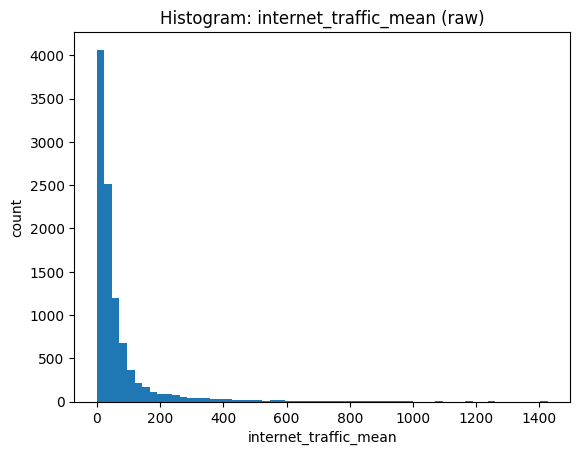

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\eda\hist_internet_traffic_mean_log1p.png


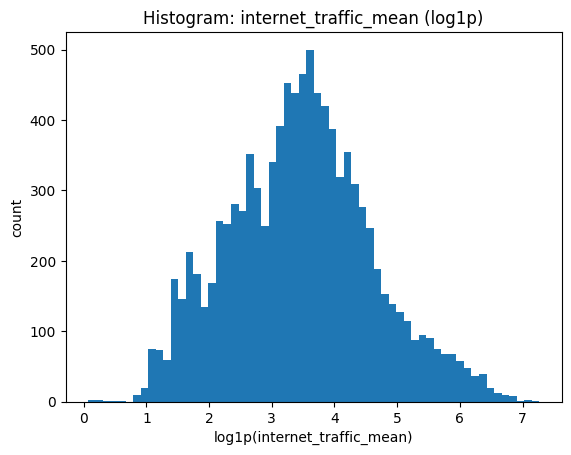

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\eda\hist_call_out_mean_raw.png


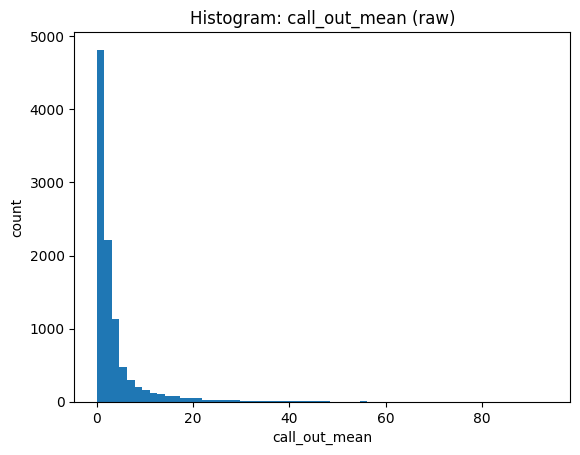

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\eda\hist_call_out_mean_log1p.png


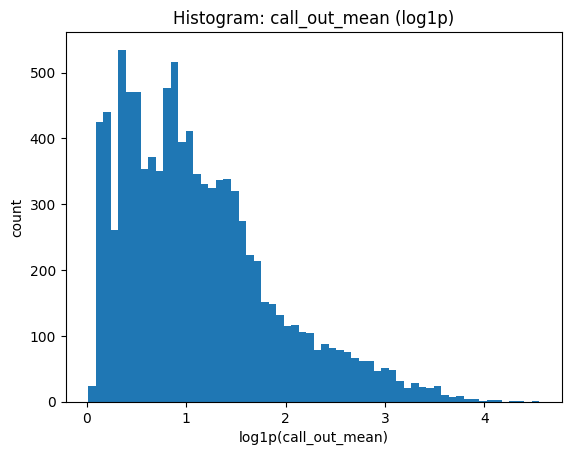

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\eda\hist_sms_out_mean_raw.png


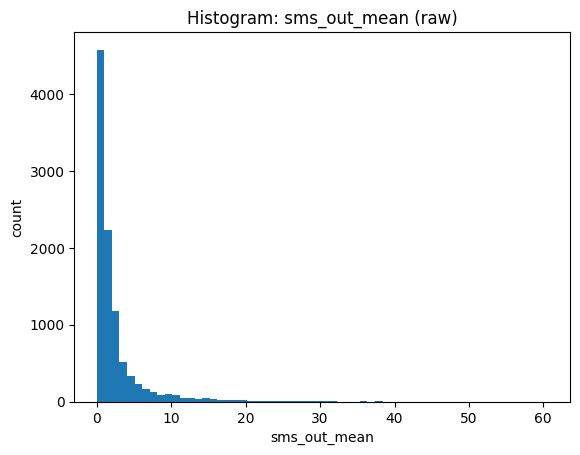

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\eda\hist_sms_out_mean_log1p.png


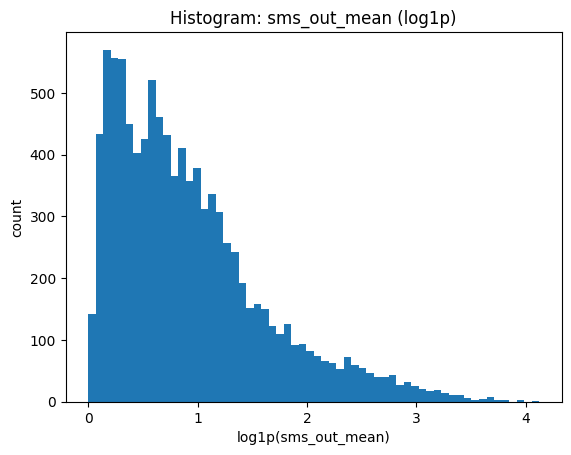

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\eda\hist_internet_traffic_max_raw.png


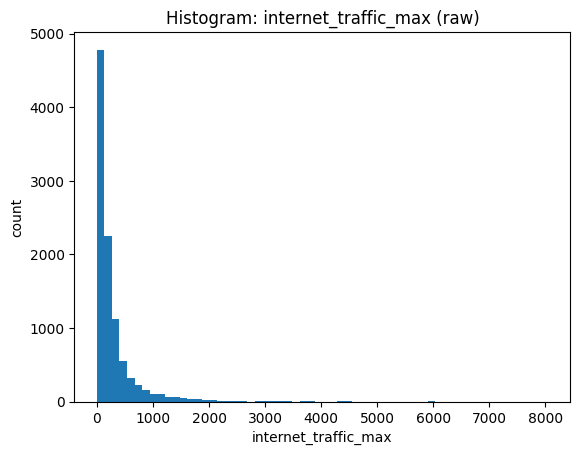

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\eda\hist_internet_traffic_max_log1p.png


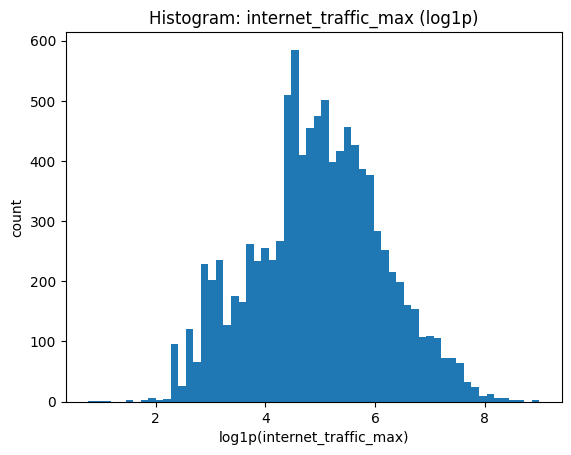

In [64]:
features_to_plot = [
    "internet_traffic_mean",
    "call_out_mean",
    "sms_out_mean",
    "internet_traffic_max",
]

for feat in features_to_plot:
    vals = X_square[feat].values

    plt.figure()
    plt.hist(vals, bins=60)
    plt.title(f"Histogram: {feat} (raw)")
    plt.xlabel(feat)
    plt.ylabel("count")
    save_fig(f"hist_{feat}_raw")
    plt.show()

    plt.figure()
    plt.hist(np.log1p(vals), bins=60)
    plt.title(f"Histogram: {feat} (log1p)")
    plt.xlabel(f"log1p({feat})")
    plt.ylabel("count")
    save_fig(f"hist_{feat}_log1p")
    plt.show()

Distributions are heavily right-skewed: raw histograms show strong heavy tails; log1p produces much more “cluster-friendly” shapes.

### Sample size analysis for Clustering

In [65]:
n_obs = X_square.shape[0]          # 10,000 squares (future clustering units)
n_features = X_square.shape[1] - 1 # excluding square_id

print("Planned clustering unit: grid cells")
print("Number of observations (grid cells):", n_obs)
print("Number of diagnostic features:", n_features)

# Guidelines: 50–100 observations per expected cluster
for k in [4, 6, 8, 10, 12]:
    print(f"If k={k}: obs/cluster ≈ {n_obs/k:.1f}")

Planned clustering unit: grid cells
Number of observations (grid cells): 10000
Number of diagnostic features: 20
If k=4: obs/cluster ≈ 2500.0
If k=6: obs/cluster ≈ 1666.7
If k=8: obs/cluster ≈ 1250.0
If k=10: obs/cluster ≈ 1000.0
If k=12: obs/cluster ≈ 833.3


### Cluster tendency: Hopkins statistic

Hopkins is expensive if you compute distances on huge/high-dim data. We’ll compute it on a random sample of grid cells and on a reasonable feature set (e.g., means/medians only). That’s standard.

In [66]:
def hopkins_statistic(X, sample_size=500, random_state=42):
    """
    Hopkins statistic:
    - ~0.5 suggests random/unclusterable structure
    - <0.5 suggests cluster tendency (more clusterable)
    """
    rng = np.random.default_rng(random_state)

    X = np.asarray(X, dtype=float)
    n, d = X.shape
    m = min(sample_size, n)

    # sample m real points
    idx = rng.choice(n, size=m, replace=False)
    X_m = X[idx]

    # generate m uniform random points in the feature-wise min/max range
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    U = rng.uniform(mins, maxs, size=(m, d))

    nn = NearestNeighbors(n_neighbors=2).fit(X)

    # distances from sampled real points to their nearest neighbor (excluding itself)
    dist_x, _ = nn.kneighbors(X_m, n_neighbors=2)
    w = dist_x[:, 1]  # second neighbor

    # distances from random points to nearest neighbor
    dist_u, _ = nn.kneighbors(U, n_neighbors=1)
    u = dist_u[:, 0]

    H = u.sum() / (u.sum() + w.sum())
    return H

# Use a reduced feature set for Hopkins (means + medians tends to be stable)
use_cols = [c for c in X_square.columns if c.endswith("_mean") or c.endswith("_median")]
X_small = X_square[use_cols].copy()

# Standardize before Hopkins (distance-based)
X_scaled = StandardScaler().fit_transform(X_small)

H = hopkins_statistic(X_scaled, sample_size=800, random_state=42)
print("Hopkins statistic (sampled):", H)

Hopkins statistic (sampled): 0.9882131059080583


In many references, Hopkins close to 1 indicates strong cluster tendency, and close to 0.5 indicates random. In other implementations the interpretation flips depending on how distances are computed (and whether you used nearest neighbor distances correctly). Because we got 0.988, we should not act on it until we verify. So we run our Hopkins function on two synthetic datasets

Hopkins on BLOBS (should be clusterable):  0.9343992474055394
Hopkins on UNIFORM (should be random):    0.0055411728685879


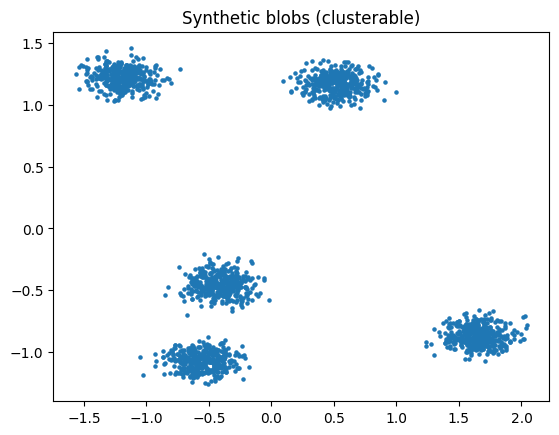

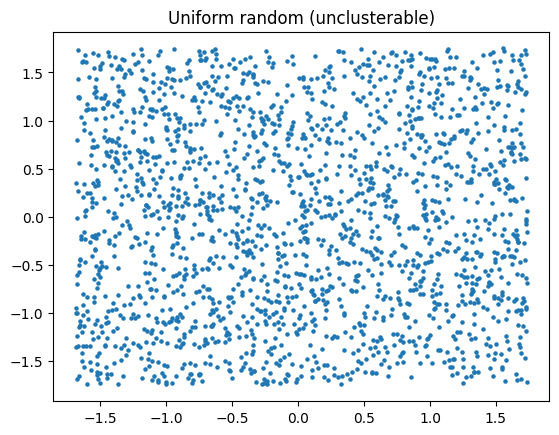

In [67]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# 1) clearly clusterable data
X_blobs, _ = make_blobs(n_samples=2000, centers=5, n_features=5, cluster_std=0.6, random_state=42)
X_blobs = StandardScaler().fit_transform(X_blobs)

# 2) uniform random data (no clusters)
rng = np.random.default_rng(42)
X_uniform = rng.uniform(low=-2, high=2, size=(2000, 5))
X_uniform = StandardScaler().fit_transform(X_uniform)

H_blobs = hopkins_statistic(X_blobs, sample_size=500, random_state=42)
H_uniform = hopkins_statistic(X_uniform, sample_size=500, random_state=42)

print("Hopkins on BLOBS (should be clusterable): ", H_blobs)
print("Hopkins on UNIFORM (should be random):   ", H_uniform)

# quick visual sanity (2D projection) - optional
plt.figure()
plt.scatter(X_blobs[:,0], X_blobs[:,1], s=5)
plt.title("Synthetic blobs (clusterable)")
plt.show()

plt.figure()
plt.scatter(X_uniform[:,0], X_uniform[:,1], s=5)
plt.title("Uniform random (unclusterable)")
plt.show()

Since H_blobs > H_uniform by a lot, we can confirm, that the Hopkins implementation is behaving consistently and therefore our implementation has a very strong cluster tendency.

### Feature correlation analysis

In [68]:
# Correlation on the same reduced feature set used above
corr = pd.DataFrame(X_scaled, columns=use_cols).corr()

# Find highly correlated pairs
thr = 0.95
pairs = []
cols = corr.columns

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.iloc[i, j]
        if abs(val) >= thr:
            pairs.append((cols[i], cols[j], val))

pairs_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "corr"]).sort_values("corr", ascending=False)
print("Highly correlated pairs (|corr| >= 0.95):", len(pairs_df))
display(pairs_df.head(30))

Highly correlated pairs (|corr| >= 0.95): 14


,feature_1,feature_2,corr
9,call_in_mean,call_out_mean,0.990260
2,sms_in_mean,call_in_mean,0.990250
5,sms_in_median,call_in_median,0.988696
3,sms_in_mean,call_out_mean,0.984532
11,call_in_median,call_out_median,0.981505
13,internet_traffic_mean,internet_traffic_median,0.977349
6,sms_in_median,call_out_median,0.976387
4,sms_in_mean,internet_traffic_mean,0.965597
10,call_in_mean,internet_traffic_mean,0.962136
8,sms_out_mean,sms_out_median,0.957842


Feature redundancy exists: 14 pairs have |corr| ≥ 0.95 (e.g., call_in_mean vs call_out_mean; mean vs median pairs), so later we should avoid stuffing the model with near-duplicates.

### Stability test

pre-stability check using K-means as a diagnostic tool: split data, cluster, compare cluster structure via silhouette and centroid similarity

In [69]:
X = X_scaled
X1, X2 = train_test_split(X, test_size=0.5, random_state=42)

def kmeans_fit_report(X, k, seed):
    km = KMeans(n_clusters=k, n_init=20, random_state=seed)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    return km.cluster_centers_, sil

for k in [4, 6, 8, 10]:
    c1, sil1 = kmeans_fit_report(X1, k, seed=1)
    c2, sil2 = kmeans_fit_report(X2, k, seed=1)

    # crude centroid similarity: mean min distance between centroids (lower is more similar)
    from sklearn.metrics import pairwise_distances
    D = pairwise_distances(c1, c2)
    centroid_match = D.min(axis=1).mean()

    print(f"k={k:2d} | silhouette split1={sil1:.3f} split2={sil2:.3f} | centroid_match(mean min dist)={centroid_match:.3f}")

k= 4 | silhouette split1=0.612 split2=0.598 | centroid_match(mean min dist)=0.500
k= 6 | silhouette split1=0.527 split2=0.535 | centroid_match(mean min dist)=1.158
k= 8 | silhouette split1=0.488 split2=0.484 | centroid_match(mean min dist)=1.581
k=10 | silhouette split1=0.454 split2=0.470 | centroid_match(mean min dist)=1.600


Stability diagnostic looks reasonable: K-means split-half silhouettes are ~0.45–0.61, best around k=4–6, with decreasing silhouette as k increases. That’s a good sign there is structure, though not proof of “true” k.

## EDA Conclusions (What we learned / what it implies)

- **Dataset scope:** ~10,000 grid cells, 8,928 unique 10-minute intervals, covering **2013-10-31 23:00 → 2014-01-01 22:50**.
- **Key integrity:** no duplicates on (`square_id`, `time_interval`), no negative activity values.
- **Coverage:** most squares have full temporal coverage (median = 8,928 intervals), but some squares are substantially lower (min ≈ 2,883). One clearly incomplete day exists (**2013-10-31**, only 6 intervals).
- **Distributions:** all activity channels are strongly right-skewed; `log1p` noticeably improves distribution shape and reduces the influence of extreme spikes.
- **Clusterability:** Hopkins validation confirms **higher Hopkins = more clusterable** in our implementation; Milan features yield a very high Hopkins value (strong cluster tendency). Split-half K-means diagnostics show reasonable stability, with best separation around **k ≈ 4–6** on summary features.
- **Redundancy:** several engineered summary features are highly correlated (|corr| ≥ 0.95), suggesting we should avoid redundant feature sets later.

**Implication for preprocessing:** In `03_preprocessing`, we will formalize choices for (i) handling partial days / low-coverage squares, (ii) applying `log1p` transforms, (iii) scaling strategy, and (iv) the final temporal feature representation used for clustering.